## 目标与运行方法

下载完整 `.ipynb`，在 VibeIt Studio 文件浏览器中使用 **+ → Import from Files** 导入并打开。按从上到下的顺序运行代码单元；阅读模式中的图表是已保存的真实运行输出。重新运行会从内嵌数据计算结果。

本课适合具备 Python 基础的本科生。先阅读每一步的方法与图注，再修改参数。AI 练习为可选部分，不需要 AI 账号即可完成核心课程。数据写在 notebook metadata 中，不需要另下载数据文件。请保持 notebook 已保存到当前工作文件夹。

学习任务是理解本课的研究问题、执行透明的计算、校验结果，并说明结论的边界。

## 环境与参数

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ch05-vapor-pressure'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### 读取内嵌快照

下面的加载函数按课程 ID 与 SHA-256 在当前文件夹定位本 notebook，解压后再次校验。文件改名不影响匹配。若找不到数据，确认当前工作目录与文件位置；不要用编造的数据替换它。metadata 随 `.ipynb` 保存及导出，复制代码到单独 `.py` 不会自动复制数据。

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'models': '48fd2e6e706650fe2ee0c0ad80b6d794a546a1dec78dd9d370ac09db3cc3adbf', 'constants': '2533802a1a546c612d06ba2e931e4f32a418be854c75a5e9c327ff57d5b56126'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['models', 'constants']


### 方法函数

本课所需函数的完整代码就在下面。它们只使用已列出的预装包与标准库，运行时不会导入任何 cookbook 辅助模块。先检查输入约束和返回值；如果修改算法，后面的校验也需要继续通过。

In [3]:
def water_saturation_pressure(temperature_K,parameters):
    """IAPWS SR1-86(1992) saturation-pressure correlation, output in pascals."""
    T=np.asarray(temperature_K,dtype=float);Tc=parameters['critical_temperature_K'];Pc=parameters['critical_pressure_Pa']
    if not np.isfinite(T).all() or np.any(T<273.16) or np.any(T>Tc):
        raise ValueError('Reference correlation requires triple-point through critical temperatures')
    tau=1-T/Tc;series=np.zeros_like(T)
    for coefficient,power in zip(parameters['coefficients'],parameters['exponents']):series+=coefficient*tau**power
    return Pc*np.exp(Tc/T*series)

print("Method ready: water_saturation_pressure")


Method ready: water_saturation_pressure


### 数据与模型边界

PubChem 性质与构象是数据库计算字段，不是新实验测量。本课 V2000 解析范围明确限定为原子、来源键型与形式电荷。滴定及校准使用已声明的理想/模拟教学假设；水蒸气压使用署名的 IAPWS 参考关联式。描述符、距离和视觉邻近不能证明生物活性或结合强度。

## 分步分析

### 1. 遵守参考关联式范围

IAPWS SR1-86(1992) 定义三相点至临界温度间的饱和压力，关联式返回绝对压力 Pa。系数及临界值来自官方发布文件，其封面允许不受限制地出版。

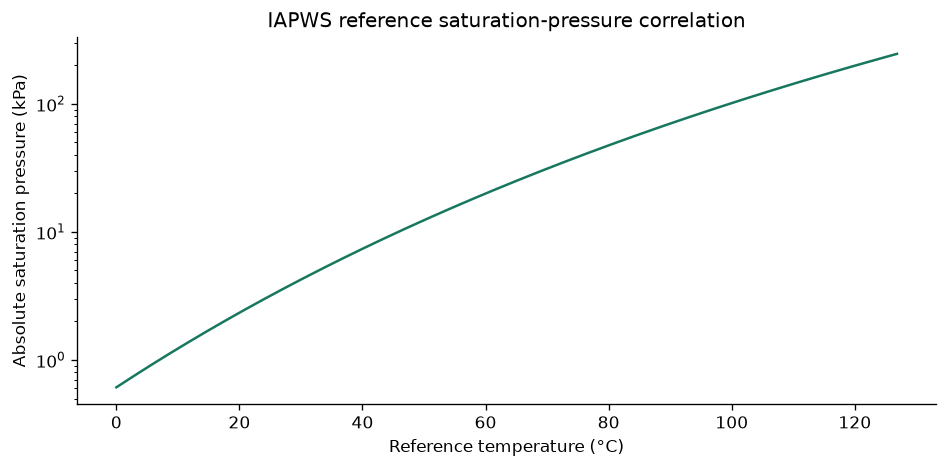

In [4]:
p=snapshot("models")["water_saturation"];R=snapshot("constants")["constants"]["R"]["value"]
temperature=np.linspace(273.16,400,501);pressure=water_saturation_pressure(temperature,p)
fig,ax=plt.subplots(figsize=(8,4));ax.semilogy(temperature-273.15,pressure/1000)
ax.set(xlabel="Reference temperature (°C)",ylabel="Absolute saturation pressure (kPa)",title="IAPWS reference saturation-pressure correlation");plt.tight_layout();plt.show()


### 2. 检查 Clausius–Clapeyron 线性近似

在理想蒸气、液体体积可忽略和恒定焓近似下，ln(P) 对 1/T 线性。对声明的 280–370 K 参考区间拟合，并单独检查残差；这些是参考计算压力，不是独立实验观测。

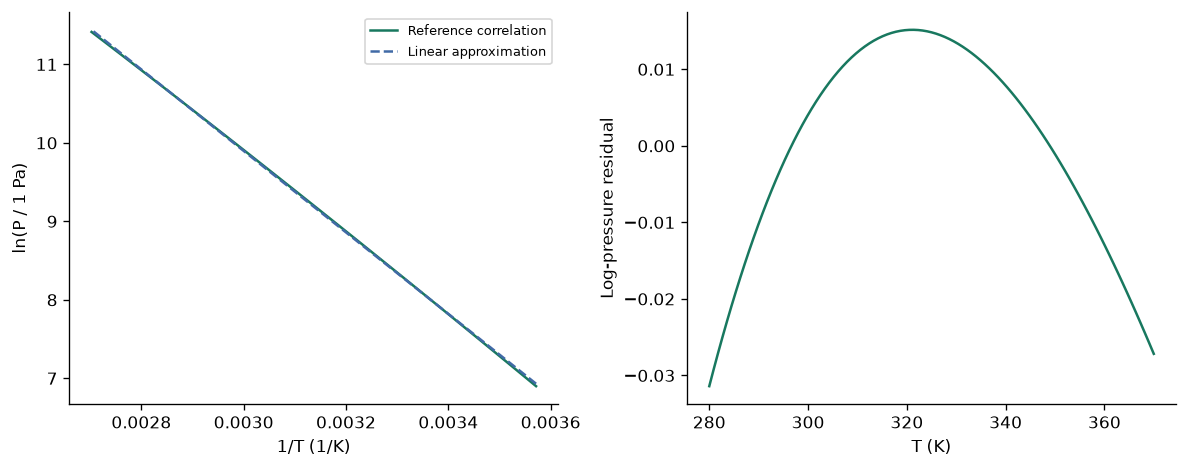

Apparent interval enthalpy under ideal-vapor approximation (kJ/mol): 43.16264125387878


In [5]:
fit_temperature=np.linspace(280,370,101);fit_pressure=water_saturation_pressure(fit_temperature,p)
coefficient=np.polyfit(1/fit_temperature,np.log(fit_pressure),1);predicted=np.polyval(coefficient,1/fit_temperature)
apparent_enthalpy=-R*coefficient[0]
fig,axes=plt.subplots(1,2,figsize=(10,4));axes[0].plot(1/fit_temperature,np.log(fit_pressure),label="Reference correlation")
axes[0].plot(1/fit_temperature,predicted,"--",label="Linear approximation");axes[0].set(xlabel="1/T (1/K)",ylabel="ln(P / 1 Pa)");axes[0].legend(fontsize=8)
axes[1].plot(fit_temperature,np.log(fit_pressure)-predicted);axes[1].set(xlabel="T (K)",ylabel="Log-pressure residual")
plt.tight_layout();plt.show();print("Apparent interval enthalpy under ideal-vapor approximation (kJ/mol):",apparent_enthalpy/1000)


### 3. 检查局部表观焓

R T² dln(P)/dT 只有在相同体积和理想蒸气近似下才给出表观摩尔汽化焓。随温度变化提示恒定焓简化；不能在临界条件下将其当作精确潜热。

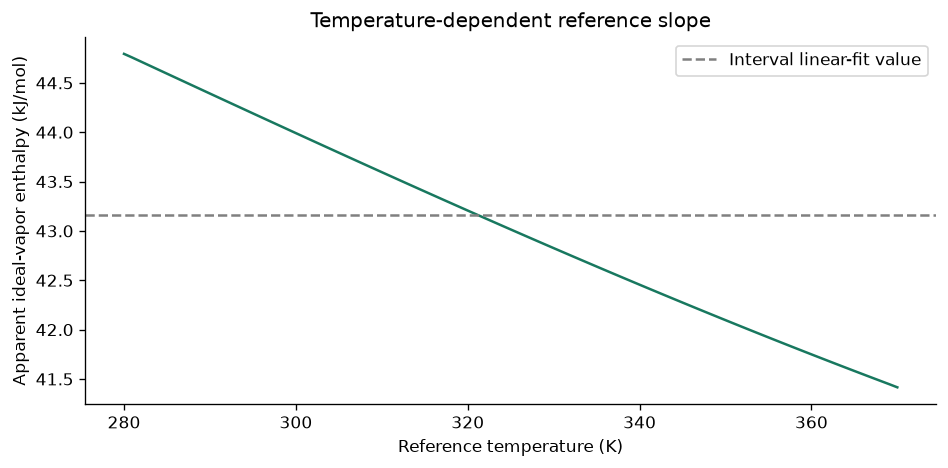

In [6]:
local=R*fit_temperature**2*np.gradient(np.log(fit_pressure),fit_temperature,edge_order=2)
fig,ax=plt.subplots(figsize=(8,4));ax.plot(fit_temperature,local/1000)
ax.axhline(apparent_enthalpy/1000,color="gray",linestyle="--",label="Interval linear-fit value")
ax.set(xlabel="Reference temperature (K)",ylabel="Apparent ideal-vapor enthalpy (kJ/mol)",title="Temperature-dependent reference slope");ax.legend();plt.tight_layout();plt.show()


### 4. 检查压力基准及拒绝外推

在声明舍入精度下复现临界压力和三相点参考。拒绝三相点以下输入，因为该式不是一般冰—蒸气方程。导出绝对单位及参考发布号。

In [7]:
assert np.isclose(water_saturation_pressure(np.array([647.096]),p)[0],22.064e6,rtol=1e-12)
assert np.isclose(water_saturation_pressure(np.array([273.16]),p)[0],611.657,rtol=5e-6)
assert np.all(np.diff(pressure)>0)
try:water_saturation_pressure(np.array([250]),p)
except ValueError:print("Below-range extrapolation rejected")
else:raise AssertionError("Unsupported temperature accepted")
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
pd.DataFrame({"temperature_K":temperature,"reference_pressure_Pa":pressure}).to_csv(OUTPUT_DIR/"reference-saturation-pressure.csv",index=False)
pd.DataFrame({"temperature_K":fit_temperature,"apparent_enthalpy_J_per_mol":local,"linear_log_pressure_residual":np.log(fit_pressure)-predicted}).to_csv(OUTPUT_DIR/"reference-approximation-audit.csv",index=False)
print("Reference-point and range checks passed; exports:",OUTPUT_DIR)


Below-range extrapolation rejected
Reference-point and range checks passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/ch05-vapor-pressure


## 自主练习与参考答案

1. 区分参考关联压力与新测量。
2. 表观焓斜率依赖哪些假设？

**参考解释。** IAPWS 是署名的参考关联式。斜率解释假定理想蒸气、忽略液体体积及焓近似，临界附近并不精确。

先保留当前 notebook 副本，再修改参数。把新图与原图一起比较，并记录改变了哪些输入、哪些计算和哪些结论。

## 可选的 AI 编程练习

在 VibeIt 的 Coding Agent 中打开当前 notebook，先让助手阅读相关单元。核心课程不依赖 AI 服务；服务可用性与账号设置以应用帮助中心为准。

**提示词 1**

> 仅用 NumPy、Pandas、Matplotlib 在有效范围比较 280–320 与 320–370 K 的线性拟合。

**提示词 2**

> 使用同样的包并允许 SciPy brentq，增加标准绝对压力下的沸点求根，注明 Pa/K。

**人工验收。** 参考点和范围约束通过，压力为绝对量，派生量保留近似标签。

检查修改后的源代码，再手动运行受影响单元及后续校验。要求助手解释修改的目的、使用的包和数据来源，并用实际输出核对解释。

## 可选联网扩展

默认关闭下面的联网操作。它只显示数据库版本及快照来源，不会替换核心数据。若要重新获取数据，应另存一个实验版本并记录新的 URL、数据库版本、获取日期与 SHA-256；新版结果需要重新执行和核验。

In [8]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://iapws.org/technical-guidance/release/Supp-sat',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## 来源、快照与下一步

- [NIST CODATA physical constants](https://physics.nist.gov/cuu/Constants/Table/allascii.txt) — NIST public reference data; credit NIST/CODATA; retrieved 2026-10-09. SHA-256 `77fb90e66c40db3e6eb16630bc9c88e4c7c8beddbe5e71be406f2f26e3f67e67`.
  Preserve official ASCII table; extract seven explicitly named SI constants and their units.

- [IAPWS saturation reference release](https://iapws.org/public/documents/6dGkr/Supp-sat.pdf) — IAPWS SR1-86(1992): unrestricted publication allowed in all countries (cover page); retrieved 2026-10-09. SHA-256 `a10d38d73339b0713c86cfac88f9adcba137202167ccdfa1cd58238c438361d7`.
  Reference equations and numerical coefficients transcribed from release pages 2–3; pedagogical model values are not new experiments.

- [Authored numerical teaching model parameters](https://github.com/zhiluo20/vibeit/blob/main/cookbook-src/freeze_subject_data.py) — Original teaching parameters/code MIT; reference equation coefficients attributed to IAPWS SR1-86(1992); retrieved 2026-10-09. SHA-256 `4350c4305a83c772fa295a8be0ef86a247f2bfaae930a081720d3cd0c753abe0`.
  Declared parameters and seed; generated trajectories and calibration observations must be labelled simulated.


**下一步。** 在保留本课的数据检查、参数记录和结果校验之后，将相同方法用于自己的公开或已获授权数据。记录研究设计与方法限制，不把示例结果当成新实验的验证。完整数据许可与生成说明见 cookbook 网页。